In [2]:
import pandas as pd
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('train.csv')
df

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,TRAIN_000,4,103,60,33,192,24.0,0.966,33,0
1,TRAIN_001,10,133,68,0,0,27.0,0.245,36,0
2,TRAIN_002,4,112,78,40,0,39.4,0.236,38,0
3,TRAIN_003,1,119,88,41,170,45.3,0.507,26,0
4,TRAIN_004,1,114,66,36,200,38.1,0.289,21,0
...,...,...,...,...,...,...,...,...,...,...
647,TRAIN_647,1,91,64,24,0,29.2,0.192,21,0
648,TRAIN_648,10,122,68,0,0,31.2,0.258,41,0
649,TRAIN_649,8,84,74,31,0,38.3,0.457,39,0
650,TRAIN_650,2,81,72,15,76,30.1,0.547,25,0


In [7]:
# 0이 실제값이 아닌 0에 none값 넣기
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI','DiabetesPedigreeFunction','Age']
df[cols] = df[cols].replace(0, np.nan) 
# 0이라는 데이터를 ' none or np.nan or pd.NA '으로 바꿔주겠다. 파이썬 버전 낮아서 NaN 안됨
df

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,TRAIN_000,4,103.0,60.0,33.0,192.0,24.0,0.966,33,0
1,TRAIN_001,10,133.0,68.0,NaN,NaN,27.0,0.245,36,0
2,TRAIN_002,4,112.0,78.0,40.0,NaN,39.4,0.236,38,0
3,TRAIN_003,1,119.0,88.0,41.0,170.0,45.3,0.507,26,0
4,TRAIN_004,1,114.0,66.0,36.0,200.0,38.1,0.289,21,0
...,...,...,...,...,...,...,...,...,...,...
647,TRAIN_647,1,91.0,64.0,24.0,NaN,29.2,0.192,21,0
648,TRAIN_648,10,122.0,68.0,NaN,NaN,31.2,0.258,41,0
649,TRAIN_649,8,84.0,74.0,31.0,NaN,38.3,0.457,39,0
650,TRAIN_650,2,81.0,72.0,15.0,76.0,30.1,0.547,25,0


In [26]:
# 결측치 확인
df.isnull().sum()

ID                            0
Pregnancies                  87
Glucose                       4
BloodPressure                30
SkinThickness               195
Insulin                     318
BMI                           7
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [55]:
# 당뇨 여부별 평균 비교
df.groupby("Outcome")[['Age','Glucose','BMI','SkinThickness']].mean()

,Age,Glucose,BMI,SkinThickness
Outcome,,,,
0,31.620283,110.703065,30.773445,27.390879
1,37.026316,142.114218,35.094273,32.786667


In [9]:
# 상관관계 분석
corr = df.select_dtypes(include=[np.number]).corr()
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.103556,0.226017,0.118096,0.053231,0.046430,-0.028958,0.511983,0.211340
Glucose,0.103556,1.000000,0.225396,0.235629,0.600420,0.237035,0.124891,0.247282,0.491411
BloodPressure,0.226017,0.225396,1.000000,0.233743,0.088252,0.298010,-0.014514,0.323619,0.174444
SkinThickness,0.118096,0.235629,0.233743,1.000000,0.203578,0.618963,0.081187,0.185974,0.245365
Insulin,0.053231,0.600420,0.088252,0.203578,1.000000,0.259904,0.174862,0.200481,0.318675
BMI,0.046430,0.237035,0.298010,0.618963,0.259904,1.000000,0.113352,0.030108,0.307655
DiabetesPedigreeFunction,-0.028958,0.124891,-0.014514,0.081187,0.174862,0.113352,1.000000,0.035520,0.173584
Age,0.511983,0.247282,0.323619,0.185974,0.200481,0.030108,0.035520,1.000000,0.218183
Outcome,0.211340,0.491411,0.174444,0.245365,0.318675,0.307655,0.173584,0.218183,1.000000


In [8]:
df.groupby("Age")[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI','DiabetesPedigreeFunction']].mean()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction
Age,,,,,,
21,110.127660,65.645833,23.023810,146.103448,28.906383,0.425229
22,110.951613,66.666667,25.274510,122.333333,30.542623,0.431365
23,113.176471,70.250000,26.379310,171.560000,31.614706,0.435235
24,116.727273,68.937500,29.965517,114.600000,33.015625,0.363273
25,107.800000,64.888889,28.677419,142.360000,31.674359,0.592900
26,118.851852,67.923077,30.181818,128.050000,34.948148,0.409519
27,115.148148,74.230769,28.411765,131.916667,31.559259,0.488111
28,123.000000,72.821429,30.347826,171.176471,33.796667,0.436100
29,126.000000,73.045455,34.285714,175.500000,33.420833,0.376167


In [28]:
df_imp = df.copy()

In [29]:
df_imp

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,TRAIN_000,4,103,60,33,192,24.0,0.966,33,0
1,TRAIN_001,10,133,68,<NA>,<NA>,27.0,0.245,36,0
2,TRAIN_002,4,112,78,40,<NA>,39.4,0.236,38,0
3,TRAIN_003,1,119,88,41,170,45.3,0.507,26,0
4,TRAIN_004,1,114,66,36,200,38.1,0.289,21,0
...,...,...,...,...,...,...,...,...,...,...
647,TRAIN_647,1,91,64,24,<NA>,29.2,0.192,21,0
648,TRAIN_648,10,122,68,<NA>,<NA>,31.2,0.258,41,0
649,TRAIN_649,8,84,74,31,<NA>,38.3,0.457,39,0
650,TRAIN_650,2,81,72,15,76,30.1,0.547,25,0


In [47]:
df['AgeBand'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60, 70, 100], labels=['20대','30대','40대','50대','60대','70대이상'])
df

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeBand
0,TRAIN_000,4,103.0,60.0,33.0,192.0,24.0,0.966,33,0,30대
1,TRAIN_001,10,133.0,68.0,NaN,NaN,27.0,0.245,36,0,30대
2,TRAIN_002,4,112.0,78.0,40.0,NaN,39.4,0.236,38,0,30대
3,TRAIN_003,1,119.0,88.0,41.0,170.0,45.3,0.507,26,0,20대
4,TRAIN_004,1,114.0,66.0,36.0,200.0,38.1,0.289,21,0,20대
...,...,...,...,...,...,...,...,...,...,...,...
647,TRAIN_647,1,91.0,64.0,24.0,NaN,29.2,0.192,21,0,20대
648,TRAIN_648,10,122.0,68.0,NaN,NaN,31.2,0.258,41,0,40대
649,TRAIN_649,8,84.0,74.0,31.0,NaN,38.3,0.457,39,0,30대
650,TRAIN_650,2,81.0,72.0,15.0,76.0,30.1,0.547,25,0,20대


In [48]:
df.groupby('AgeBand')['Glucose'].mean()

/var/folders/7d/4294lrxx67jdcn0_3qst6jf00000gn/T/ipykernel_8943/1026279027.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeBand')['Glucose'].mean()


AgeBand
20대      115.049708
30대      126.911765
40대      126.130000
50대      140.340426
60대      132.761905
70대이상    126.500000
Name: Glucose, dtype: float64

In [49]:
glucose_mean = df.groupby('AgeBand')['Glucose'].transform('mean')

/var/folders/7d/4294lrxx67jdcn0_3qst6jf00000gn/T/ipykernel_8943/3501649691.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  glucose_mean = df.groupby('AgeBand')['Glucose'].transform('mean')


In [50]:
df['Glucose'] = df['Glucose'].fillna(glucose_mean)
df.isnull().sum()

ID                            0
Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               195
Insulin                     318
BMI                           7
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
AgeBand                       0
dtype: int64

In [54]:
df.groupby('Age')['BloodPressure'].mean()

Age
21    65.645833
22    66.767407
23    70.163659
24    68.932794
25    65.278221
26    67.954897
27    74.028971
28    72.552147
29    72.690184
30    70.975801
31    73.589423
32    74.714359
33    65.375000
34    73.230769
35    72.500000
36    75.809615
37    79.666667
38    74.747337
39    72.666667
40    75.309615
41    75.041237
42    73.187500
43    81.333333
44    81.108247
45    81.166667
46    76.000000
47    79.600000
48    75.000000
49    81.400000
50    78.250000
51    81.000000
52    81.500000
53    76.750000
54    88.000000
55    70.250000
56    76.333333
57    77.000000
58    78.800000
59    74.000000
60    80.000000
61    60.000000
62    69.333333
63    78.000000
64    78.000000
65    78.666667
66    84.000000
67    69.000000
68    82.000000
69    81.000000
70    82.000000
72    74.000000
81    74.000000
Name: BloodPressure, dtype: float64

In [52]:
bp_mean = df.groupby('AgeBand')['BloodPressure'].transform('mean')
bp_mean

/var/folders/7d/4294lrxx67jdcn0_3qst6jf00000gn/T/ipykernel_8943/689424859.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bp_mean = df.groupby('AgeBand')['BloodPressure'].transform('mean')


0      73.715385
1      73.715385
2      73.715385
3      68.782209
4      68.782209
         ...    
647    68.782209
648    77.432990
649    73.715385
650    68.782209
651    68.782209
Name: BloodPressure, Length: 652, dtype: float64

In [53]:
df['BloodPressure'] = df['BloodPressure'].fillna(bp_mean)

In [36]:
df.isnull().sum()

ID                            0
Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               195
Insulin                     318
BMI                           7
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
AgeBand                       0
dtype: int64

<Axes: xlabel='Glucose', ylabel='Count'>

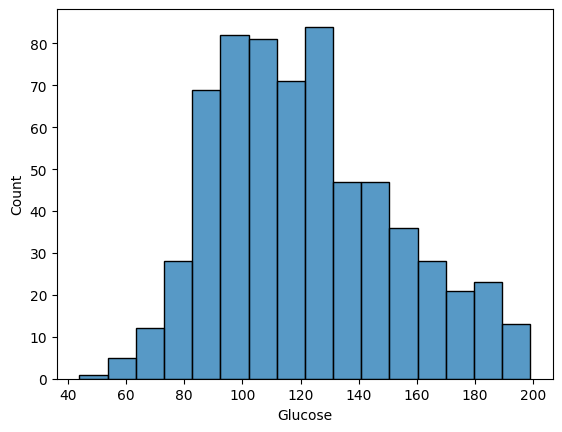

In [21]:
#시각화
sns.histplot(df['Glucose'])

<Axes: xlabel='Glucose', ylabel='Age'>

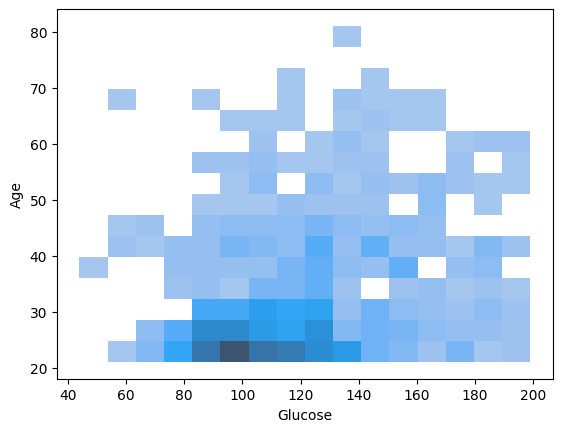

In [38]:
sns.histplot(df, x='Glucose',y='Age')

<Axes: xlabel='Outcome', ylabel='Glucose'>

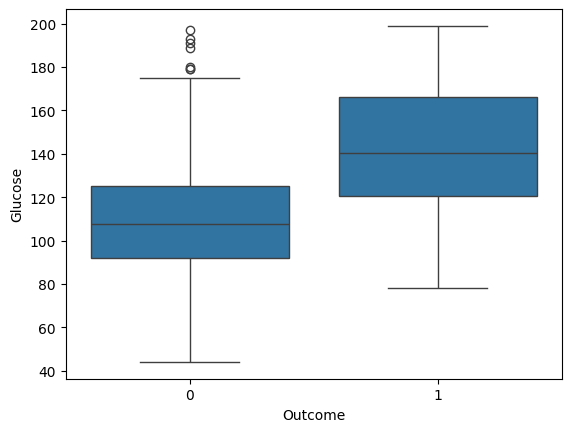

In [39]:
sns.boxplot(df, x='Outcome',y='Glucose') # x값에는 범주형 데이터가 어울림

<Axes: ylabel='Glucose'>

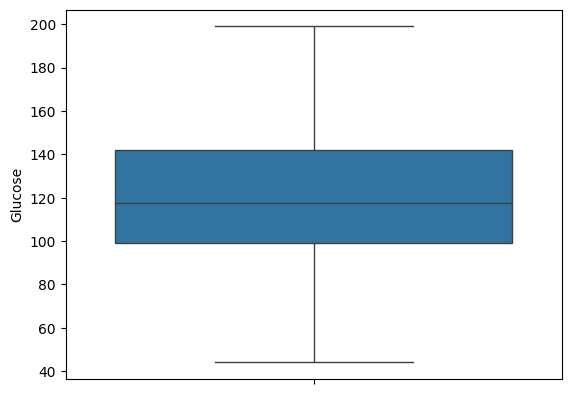

In [56]:
sns.boxplot(df['Glucose'])

<Axes: xlabel='Outcome', ylabel='Glucose'>

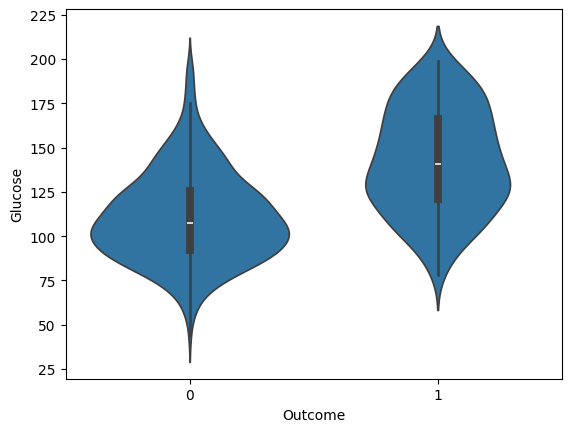

In [58]:
sns.violinplot(df,x='Outcome',y='Glucose') #축에는 범주형 데이터가 어울림

<Axes: xlabel='Glucose', ylabel='BMI'>

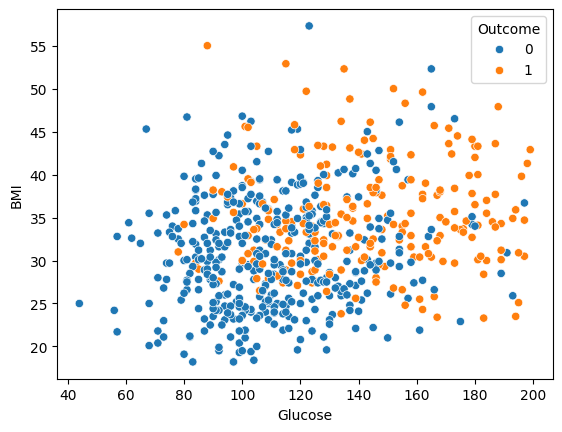

In [40]:
# Glucose
sns.scatterplot(df, x='Glucose', y='BMI', hue='Outcome')

<Axes: >

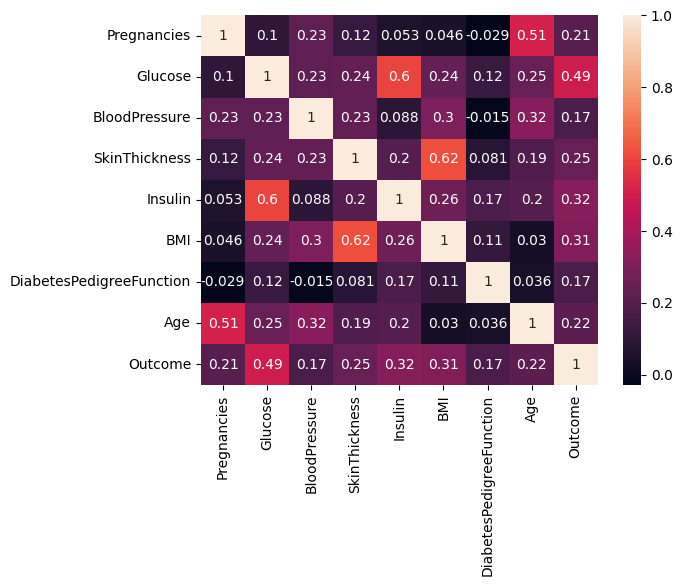

In [42]:
sns.heatmap(corr, annot=True)